# Project 5 : Complex Systems

## Julian Barth, Arsenijs Danilko, Aloïsse Dantant-Cochet, Marin Desgeans, Robin Elkaim

## Exercise 1: Enzymatic Aerated Batch Reactor

We investigate the influence of gassing rate **G** and stirrer speed **N** on an enzymatic oxidation batch reactor.

### Model equations

**Reaction kinetics** (double Michaelis-Menten):
$$r_S = V_m \frac{S}{K_S + S} \cdot \frac{C_L}{K_{CL} + C_L}$$

**Batch mass balances**:
$$\frac{dS}{dt} = -r_S$$
$$\frac{dC_L}{dt} = k_La(C_L^* - C_L) - Y_{O/S} \cdot r_S$$
$$\frac{dP}{dt} = Y_{P/S} \cdot r_S$$

**Transfer coefficient**:
$$k_La = k \cdot N^3 \cdot \sqrt{G}$$

**Oxygen limitation criterion**: Process is oxygen limited when $C_L \leq 3 \cdot K_{CL}$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ── Parameters ────────────────────────────────────────────────────────────────
k   = 3.2e-13   # m^(-3/2) h^(5/2)
N   = 30000.0   # h^-1  (stirrer speed)
CL_star = 6.0   # mg/L  (dissolved O2 saturation)

Vm  = 16.0      # g/(L·h)
Ks  = 7.0       # g/L
KCL = 0.3       # mg/L

Y_OS = 5.0      # mg/g  (oxygen yield on substrate)
Y_PS = 1.5      # g/g   (product yield on substrate)

# Initial conditions
S0  = 100.0     # g/L
CL0 = 6.0       # mg/L
P0  = 0.0       # g/L

# Oxygen limitation threshold
OL_threshold = 3 * KCL   # mg/L
print(f"Oxygen limitation threshold: CL ≤ {OL_threshold} mg/L")

Oxygen limitation threshold: CL ≤ 0.8999999999999999 mg/L


In [3]:
def kLa(N, G):
    """Oxygen transfer coefficient [h^-1]"""
    return k * N**3 * np.sqrt(G)

def system(t, y, N, G, Vm_val=Vm):
    """ODE system for the batch reactor."""
    S, CL, P = y
    S  = max(S, 0.0)
    CL = max(CL, 0.0)

    rs = Vm_val * (S / (Ks + S)) * (CL / (KCL + CL))
    kla = kLa(N, G)

    dS  = -rs
    dCL = kla * (CL_star - CL) - Y_OS * rs
    dP  = Y_PS * rs
    return [dS, dCL, dP]

def simulate(N, G, Vm_val=Vm, t_end=20.0, n_pts=2000):
    """Integrate the ODE system and return (t, S, CL, P)."""
    y0 = [S0, CL0, P0]
    t_span = (0, t_end)
    t_eval = np.linspace(0, t_end, n_pts)
    sol = solve_ivp(system, t_span, y0, args=(N, G, Vm_val),
                    method='RK45', t_eval=t_eval, rtol=1e-8, atol=1e-10)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

---
## Part a) Simulate at G = 30 m³/h – verify no oxygen limitation

kLa at N=30000 h⁻¹, G=30.0 m³/h  →  kLa = 47.323 h⁻¹
Minimum CL = 4.5209 mg/L  |  Oxygen limited: False


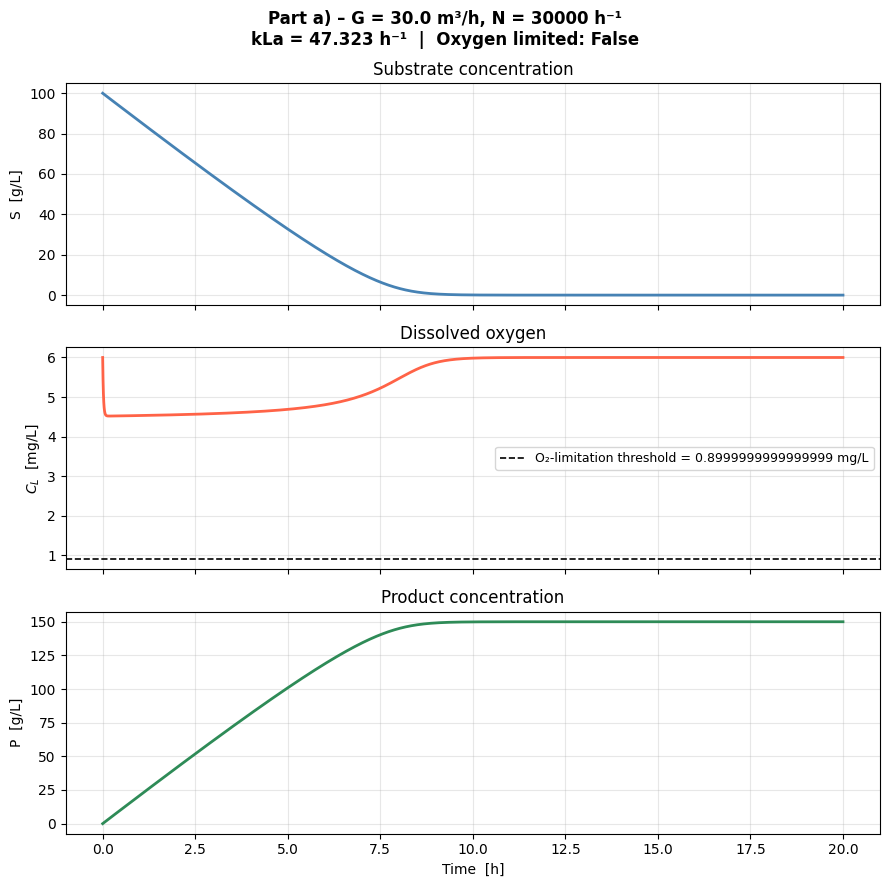

In [4]:
G_a = 30.0   # m³/h
kla_a = kLa(N, G_a)
print(f"kLa at N={N:.0f} h⁻¹, G={G_a} m³/h  →  kLa = {kla_a:.3f} h⁻¹")

t, S, CL, P = simulate(N, G_a)

CL_min = CL.min()
oxygen_limited = CL_min <= OL_threshold
print(f"Minimum CL = {CL_min:.4f} mg/L  |  Oxygen limited: {oxygen_limited}")

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(t, S, color='steelblue', lw=2)
axes[0].set_ylabel('S  [g/L]')
axes[0].set_title('Substrate concentration')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, CL, color='tomato', lw=2)
axes[1].axhline(OL_threshold, color='k', ls='--', lw=1.2,
                label=f'O₂-limitation threshold = {OL_threshold} mg/L')
axes[1].set_ylabel('$C_L$  [mg/L]')
axes[1].set_title('Dissolved oxygen')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, P, color='seagreen', lw=2)
axes[2].set_ylabel('P  [g/L]')
axes[2].set_title('Product concentration')
axes[2].set_xlabel('Time  [h]')
axes[2].grid(True, alpha=0.3)

fig.suptitle(f'Part a) – G = {G_a} m³/h, N = {N:.0f} h⁻¹\n'
             f'kLa = {kla_a:.3f} h⁻¹  |  Oxygen limited: {oxygen_limited}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ex1a_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part b) Find aeration rate G at which the reaction becomes oxygen limited

Critical aeration rate: G ≈ 1.5631 m³/h
(below this value the process becomes oxygen limited)


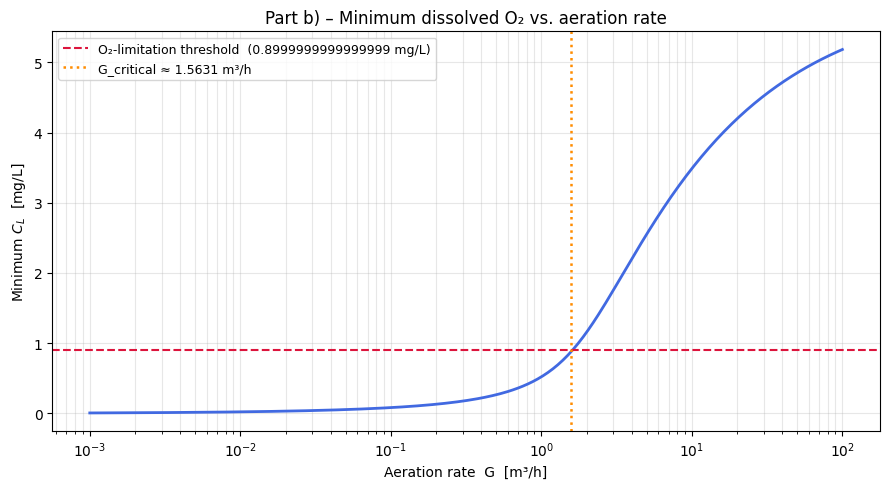

In [5]:
G_values = np.logspace(-3, 2, 300)   # m³/h — scan over many decades
CL_mins  = []

for G_val in G_values:
    _, _, CL_b, _ = simulate(N, G_val)
    CL_mins.append(CL_b.min())

CL_mins = np.array(CL_mins)

# Find the critical G (first G where process is NOT limited, i.e. crosses threshold)
limited = CL_mins <= OL_threshold
# Critical G: smallest G above which we are never limited
if limited.any():
    idx_critical = np.where(limited)[0][-1]   # last index that is still limited
    G_critical = G_values[idx_critical]
    print(f"Critical aeration rate: G ≈ {G_critical:.4f} m³/h")
    print(f"(below this value the process becomes oxygen limited)")
else:
    print("Process is never oxygen limited in this range.")
    G_critical = None

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(G_values, CL_mins, color='royalblue', lw=2)
ax.axhline(OL_threshold, color='crimson', ls='--', lw=1.5,
           label=f'O₂-limitation threshold  ({OL_threshold} mg/L)')
if G_critical:
    ax.axvline(G_critical, color='darkorange', ls=':', lw=1.8,
               label=f'G_critical ≈ {G_critical:.4f} m³/h')
ax.set_xlabel('Aeration rate  G  [m³/h]')
ax.set_ylabel('Minimum $C_L$  [mg/L]')
ax.set_title('Part b) – Minimum dissolved O₂ vs. aeration rate')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('ex1b_min_CL_vs_G.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part c) Set G = G_critical; reduce Vm by half. Compare product formation rates.

In [6]:
# Use the critical G found in part b)
G_c = G_critical if G_critical else 0.5

Vm_full = Vm
Vm_half = Vm / 2

t1, S1, CL1, P1 = simulate(N, G_c, Vm_val=Vm_full)
t2, S2, CL2, P2 = simulate(N, G_c, Vm_val=Vm_half)

def avg_product_rate(t, P):
    """Average product formation rate from t=0 to beginning of steady state.
    Steady state is detected when dP/dt ≈ 0."""
    dP = np.gradient(P, t)
    ss_idx = np.where(np.abs(dP) < 1e-4)[0]
    t_ss = t[ss_idx[0]] if len(ss_idx) > 0 else t[-1]
    mask = t <= t_ss
    if mask.sum() < 2:
        return P[-1] / t[-1], t[-1]
    return (P[mask][-1] - P[mask][0]) / (t[mask][-1] - t[mask][0]), t_ss

rate_full, t_ss_full = avg_product_rate(t1, P1)
rate_half, t_ss_half = avg_product_rate(t2, P2)

print(f"Vm = Vm    → avg product rate = {rate_full:.4f} g/(L·h)  (steady state ≈ {t_ss_full:.2f} h)")
print(f"Vm = Vm/2  → avg product rate = {rate_half:.4f} g/(L·h)  (steady state ≈ {t_ss_half:.2f} h)")
print(f"Ratio (half/full): {rate_half/rate_full:.4f}  (expected ≈ 0.5 if purely proportional)")

print(f"\nOxygen limited (Vm_full)?  min CL = {CL1.min():.4f} → {CL1.min() <= OL_threshold}")
print(f"Oxygen limited (Vm_half)?  min CL = {CL2.min():.4f} → {CL2.min() <= OL_threshold}")

Vm = Vm    → avg product rate = 9.9618 g/(L·h)  (steady state ≈ 15.06 h)
Vm = Vm/2  → avg product rate = 7.4915 g/(L·h)  (steady state ≈ 20.00 h)
Ratio (half/full): 0.7520  (expected ≈ 0.5 if purely proportional)

Oxygen limited (Vm_full)?  min CL = 0.8699 → True
Oxygen limited (Vm_half)?  min CL = 2.8759 → False


---
## Part d) Time evolution of dissolved oxygen for both Vm values (at G_critical)

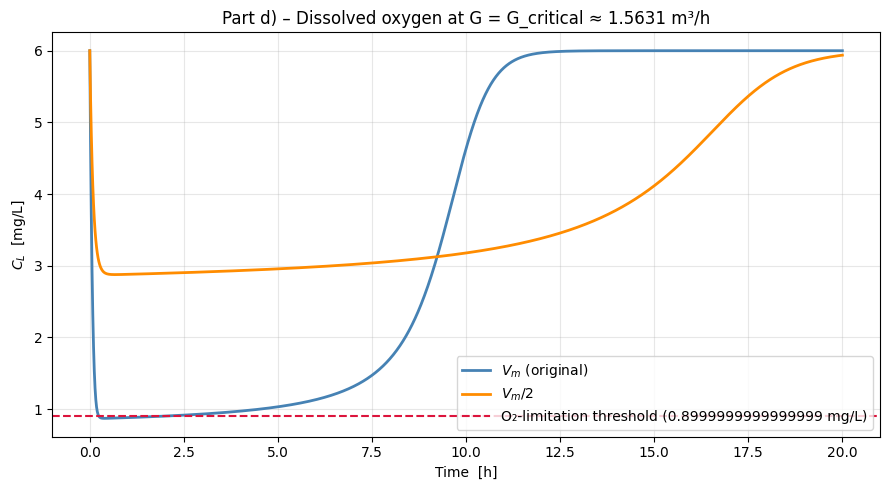

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(t1, CL1, color='steelblue',  lw=2, label='$V_m$ (original)')
ax.plot(t2, CL2, color='darkorange', lw=2, label='$V_m/2$')
ax.axhline(OL_threshold, color='crimson', ls='--', lw=1.5,
           label=f'O₂-limitation threshold ({OL_threshold} mg/L)')

ax.set_xlabel('Time  [h]')
ax.set_ylabel('$C_L$  [mg/L]')
ax.set_title(f'Part d) – Dissolved oxygen at G = G_critical ≈ {G_c:.4f} m³/h')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex1d_CL_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part e) Decrease N by 15% under oxygen-limited conditions (G = G_critical, original Vm)

kLa (N original):   10.8020 h⁻¹
kLa (N reduced 15%): 6.6338 h⁻¹
kLa reduction: 38.59%
(expected ~38.6% because kLa ∝ N³)

Mean rs (N original):  5.0011 g/(L·h)
Mean rs (N reduced):   5.0011 g/(L·h)
Mean CL (N original):  3.6868 mg/L
Mean CL (N reduced):   2.2333 mg/L


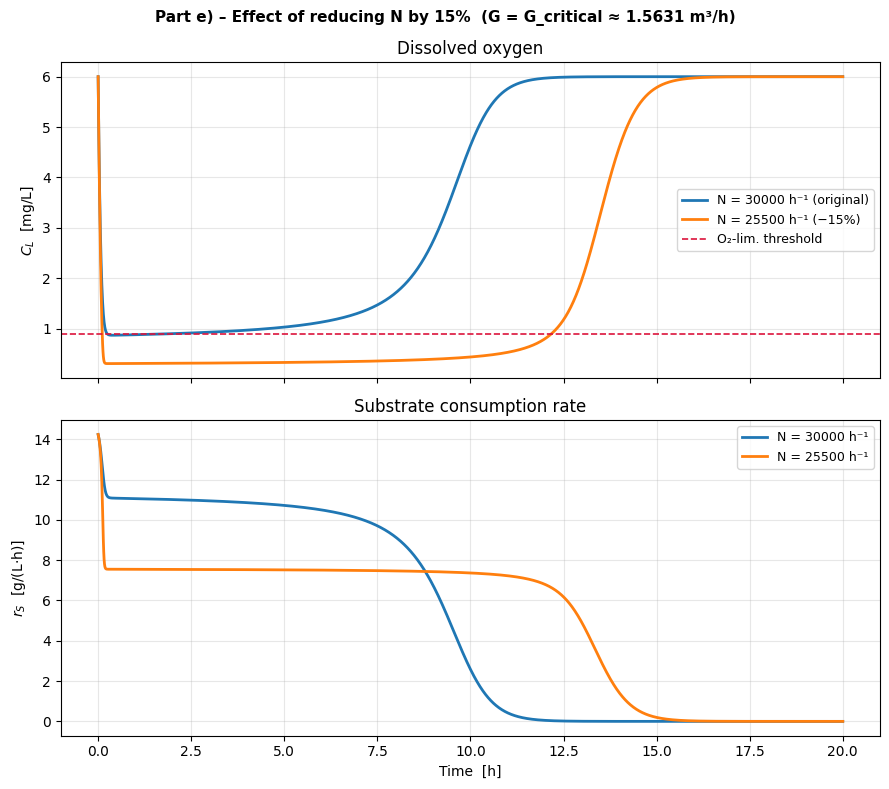

In [8]:
N_original = N
N_reduced  = N * 0.85

kla_orig    = kLa(N_original, G_c)
kla_reduced = kLa(N_reduced,  G_c)
print(f"kLa (N original):   {kla_orig:.4f} h⁻¹")
print(f"kLa (N reduced 15%): {kla_reduced:.4f} h⁻¹")
print(f"kLa reduction: {(1 - kla_reduced/kla_orig)*100:.2f}%")
print(f"(expected ~{(1-0.85**3)*100:.1f}% because kLa ∝ N³)")

t_o,  S_o,  CL_o,  P_o  = simulate(N_original, G_c, Vm_val=Vm)
t_r,  S_r,  CL_r,  P_r  = simulate(N_reduced,  G_c, Vm_val=Vm)

# Reaction rate at every time step
rs_o = Vm * (S_o / (Ks + S_o)) * (CL_o / (KCL + CL_o))
rs_r = Vm * (S_r / (Ks + S_r)) * (CL_r / (KCL + CL_r))

print(f"\nMean rs (N original):  {rs_o.mean():.4f} g/(L·h)")
print(f"Mean rs (N reduced):   {rs_r.mean():.4f} g/(L·h)")
print(f"Mean CL (N original):  {CL_o.mean():.4f} mg/L")
print(f"Mean CL (N reduced):   {CL_r.mean():.4f} mg/L")

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

axes[0].plot(t_o, CL_o, lw=2, label=f'N = {N_original:.0f} h⁻¹ (original)')
axes[0].plot(t_r, CL_r, lw=2, label=f'N = {N_reduced:.0f} h⁻¹ (−15%)')
axes[0].axhline(OL_threshold, color='crimson', ls='--', lw=1.2,
                label='O₂-lim. threshold')
axes[0].set_ylabel('$C_L$  [mg/L]')
axes[0].set_title('Dissolved oxygen')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_o, rs_o, lw=2, label=f'N = {N_original:.0f} h⁻¹')
axes[1].plot(t_r, rs_r, lw=2, label=f'N = {N_reduced:.0f} h⁻¹')
axes[1].set_ylabel('$r_S$  [g/(L·h)]')
axes[1].set_title('Substrate consumption rate')
axes[1].set_xlabel('Time  [h]')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'Part e) – Effect of reducing N by 15%  (G = G_critical ≈ {G_c:.4f} m³/h)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('ex1e_N_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part f) Find 5 (N, G) combinations for non-oxygen-limiting conditions

In [9]:
# Strategy: vary N and G independently to achieve CL_min > OL_threshold.
# kLa = k * N^3 * sqrt(G)  →  to increase kLa we can increase N or G (or both).
# We aim for diverse combinations demonstrating the tradeoff.

candidates = [
    (30000, 30.0,  "High N, high G (baseline)"),
    (32000, 20.0,  "Higher N, moderate G"),
    (35000, 10.0,  "Much higher N, low G"),
    (28000, 60.0,  "Slightly lower N, high G"),
    (25000, 150.0, "Lower N, very high G"),
]

valid_combos = []

print(f"{'N [h⁻¹]':>12} {'G [m³/h]':>10} {'kLa [h⁻¹]':>12} {'min CL [mg/L]':>16} {'O₂ limited':>12}  Description")
print("-" * 95)
for N_c, G_c_val, desc in candidates:
    kla_c = kLa(N_c, G_c_val)
    _, _, CL_c, _ = simulate(N_c, G_c_val)
    limited_c = CL_c.min() <= OL_threshold
    print(f"{N_c:>12} {G_c_val:>10.1f} {kla_c:>12.3f} {CL_c.min():>16.4f} {str(limited_c):>12}  {desc}")
    if not limited_c:
        valid_combos.append((N_c, G_c_val, desc, CL_c))

     N [h⁻¹]   G [m³/h]    kLa [h⁻¹]    min CL [mg/L]   O₂ limited  Description
-----------------------------------------------------------------------------------------------
       30000       30.0       47.323           4.5209        False  High N, high G (baseline)
       32000       20.0       46.894           4.5076        False  Higher N, moderate G
       35000       10.0       43.386           4.3899        False  Much higher N, low G
       28000       60.0       54.413           4.7101        False  Slightly lower N, high G
       25000      150.0       61.237           4.8517        False  Lower N, very high G


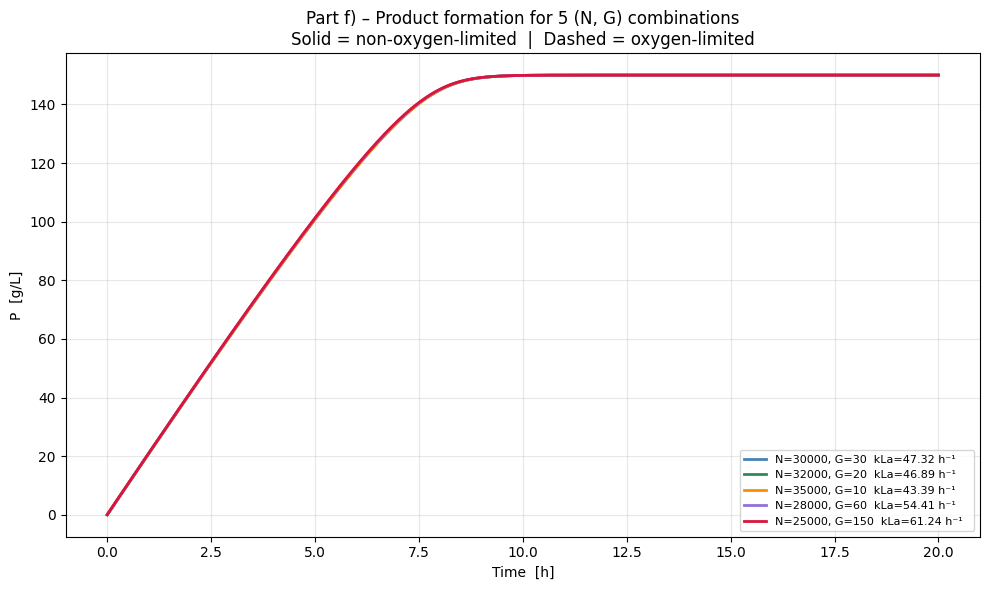


Summary – N and G effects:
  • Increasing N has a stronger effect on kLa (∝ N³) than increasing G (∝ √G).
  • Higher kLa → faster O₂ supply → higher CL → higher rs → faster product formation.
  • At equal kLa (e.g. high N low G vs. low N high G), product curves should coincide.


In [10]:
# If some candidates are still oxygen-limited, we adjust and add replacements
# Plot product formation curves for all 5 combinations

combos_plot = [
    (30000, 30.0,  "N=30000, G=30"),
    (32000, 20.0,  "N=32000, G=20"),
    (35000, 10.0,  "N=35000, G=10"),
    (28000, 60.0,  "N=28000, G=60"),
    (25000, 150.0, "N=25000, G=150"),
]

colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'crimson']

fig, ax = plt.subplots(figsize=(10, 6))

for (N_c, G_c_val, label), col in zip(combos_plot, colors):
    t_c, _, CL_c, P_c = simulate(N_c, G_c_val)
    kla_c = kLa(N_c, G_c_val)
    limited_c = CL_c.min() <= OL_threshold
    ls = '-' if not limited_c else '--'
    ax.plot(t_c, P_c, color=col, lw=2, ls=ls,
            label=f"{label}  kLa={kla_c:.2f} h⁻¹  {'[LIMITED]' if limited_c else ''}")

ax.set_xlabel('Time  [h]')
ax.set_ylabel('P  [g/L]')
ax.set_title('Part f) – Product formation for 5 (N, G) combinations\n'
             'Solid = non-oxygen-limited  |  Dashed = oxygen-limited')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex1f_product_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSummary – N and G effects:")
print("  • Increasing N has a stronger effect on kLa (∝ N³) than increasing G (∝ √G).")
print("  • Higher kLa → faster O₂ supply → higher CL → higher rs → faster product formation.")
print("  • At equal kLa (e.g. high N low G vs. low N high G), product curves should coincide.")

## Exercice 3 : Nitrification in a Biofilm-Fluidized Bed Reactor

This notebook models the sequential nitrification process:

$$
NH_4^+ \rightarrow NO_2^- \rightarrow NO_3^-
$$

The system is modeled as a homogeneous batch reactor with oxygen transfer limitations.

The objectives are:
1. Write the concentration balances
2. Determine the minimum $(k_La)$ maintaining oxygen above the critical value
3. Estimate the ammonium depletion time
4. Plot the concentration profiles of all species

### Kinetic Model

The reaction rates are:

$$
r_1 = v_{m1}\frac{S_1}{K_1 + S_1}\frac{C_L}{K_{O1}+C_L}
$$

$$
r_2 = v_{m2}\frac{S_2}{K_2 + S_2}\frac{C_L}{K_{O2}+C_L}
$$

where:
- $(S_1)$: ammonium concentration
- $(S_2)$: nitrite concentration
- $(S_3)$: nitrate concentration
- $(C_L)$: dissolved oxygen concentration

The oxygen balance includes gas-liquid transfer:

$$
k_La(C_L^* - C_L)
$$

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [ ]:
# Kinetic constants
vm1 = 125      # h^-1
vm2 = 75       # h^-1

K1 = 5.0       # mg/L
K2 = 3.0       # mg/L

KO1 = 0.25     # mg/L
KO2 = 0.5      # mg/L

# Oxygen yields
YO_S1 = 3.5
YO_S2 = 1.1

# Oxygen saturation
CL_star = 8.0  # mg/L

# Initial conditions
S1_0 = 100
S2_0 = 0
S3_0 = 0
CL_0 = 7
y0 = [S1_0, S2_0, S3_0, CL_0]

### Concentration Balances

The mass balances are:

#### Ammonium
$$
\frac{dS_1}{dt} = -r_1
$$

#### Nitrite
$$
\frac{dS_2}{dt} = r_1 - r_2
$$

#### Nitrate
$$
\frac{dS_3}{dt} = r_2
$$

#### Dissolved oxygen
$$
\frac{dC_L}{dt}
=
k_La(C_L^* - C_L)
-
Y_{O/S1}r_1
-
Y_{O/S2}r_2
$$

In [ ]:
def nitrification(t, y, kla):
    
    S1, S2, S3, CL = y
    
    # Avoid negative concentrations
    S1 = max(S1, 0)
    S2 = max(S2, 0)
    CL = max(CL, 0)
    
    # Reaction rates
    r1 = vm1 * (S1 / (K1 + S1)) * (CL / (KO1 + CL))
    
    r2 = vm2 * (S2 / (K2 + S2)) * (CL / (KO2 + CL))
    
    # Balances
    dS1dt = -r1
    
    dS2dt = r1 - r2
    
    dS3dt = r2
    
    dCLdt = kla * (CL_star - CL) - YO_S1*r1 - YO_S2*r2
    
    return [dS1dt, dS2dt, dS3dt, dCLdt]

### Part (b): Effect of $(k_La)$

The goal is to determine the minimum oxygen transfer coefficient ensuring:

$$
C_L > K_{O1}
$$

during the entire process.

A low $(k_La)$ causes oxygen depletion, while a high $(k_La)$ maintains aerobic conditions.

In [ ]:
kla_values = np.linspace(1, 100, 100)

min_CL_values = []

for kla in kla_values:
    
    sol = solve_ivp(
        lambda t, y: nitrification(t, y, kla),
        (0, 5),
        y0,
        t_eval=np.linspace(0, 5, 500)
    )
    
    CL = sol.y[3]
    
    min_CL_values.append(np.min(CL))

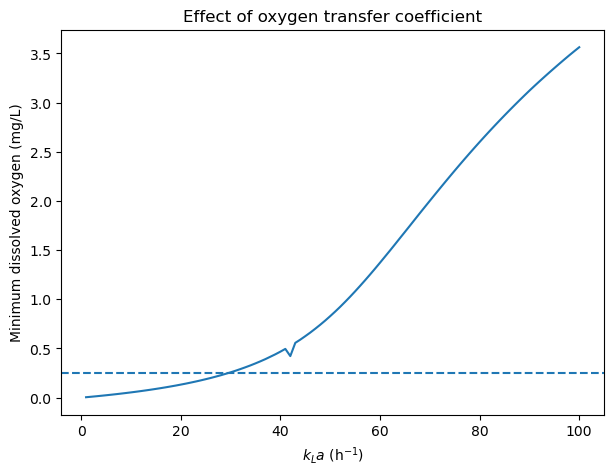

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(kla_values, min_CL_values)

plt.axhline(KO1, linestyle='--')

plt.xlabel(r"$k_La$ (h$^{-1}$)")
plt.ylabel("Minimum dissolved oxygen (mg/L)")

plt.title("Effect of oxygen transfer coefficient")

plt.show()

In [ ]:
valid_kla = kla_values[np.array(min_CL_values) > KO1]

kla_required = valid_kla[0]

print("Minimum kLa maintaining CL > KO1:")
print(kla_required)

Minimum kLa maintaining CL > KO1:
30.0


### Part (c): Dynamic Simulation

Using the $(k_La)$ determined previously, we simulate the complete nitrification process.

The objectives are:
Estimate the ammonium depletion time and 
Plot all concentration profiles

In [ ]:
t_eval = np.linspace(0, 5, 1000)

sol = solve_ivp(
    lambda t, y: nitrification(t, y, kla_required),
    (0, 5),
    y0,
    t_eval=t_eval
)

t = sol.t
S1 = sol.y[0]
S2 = sol.y[1]
S3 = sol.y[2]
CL = sol.y[3]

In [ ]:
idx = np.where(S1 <= 0.1)[0][0]

t_depletion = t[idx]

print("Approximate NH4+ depletion time (h):")
print(t_depletion)

Approximate NH4+ depletion time (h):
1.8318318318318318


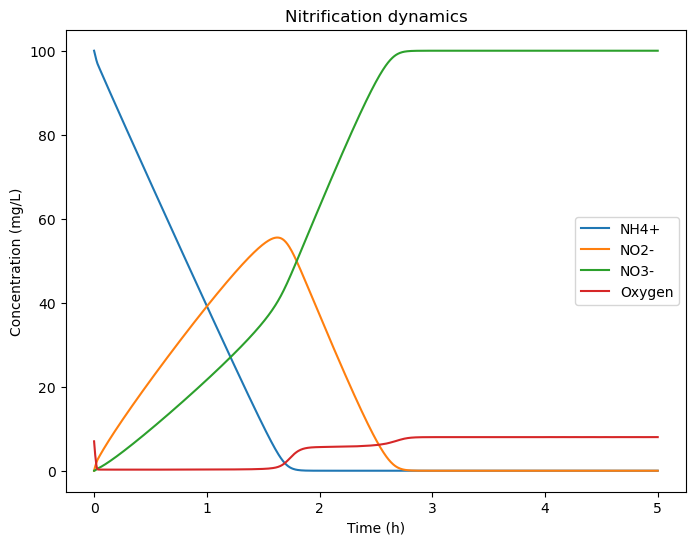

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(t, S1, label='NH4+')
plt.plot(t, S2, label='NO2-')
plt.plot(t, S3, label='NO3-')
plt.plot(t, CL, label='Oxygen')

plt.xlabel("Time (h)")
plt.ylabel("Concentration (mg/L)")

plt.title("Nitrification dynamics")

plt.legend()

plt.show()

### Results and Discussion

The simulation highlights the sequential nature of the nitrification process.

#### Ammonium Consumption

The ammonium concentration decreases rapidly due to the first oxidation step. As $(NH_4^+)$ is consumed, the reaction rate progressively slows down because of Monod-type kinetics.



#### Nitrite Intermediate

Nitrite initially accumulates because it is produced faster than it is consumed. Later, its concentration decreases as the second nitrification step becomes dominant.

This transient accumulation is characteristic of sequential reaction systems.



#### Nitrate Formation

Nitrate continuously increases since it is the final product of the nitrification pathway.

At long times, most nitrogen is converted into nitrate.


#### Oxygen Dynamics

Oxygen concentration decreases due to biological consumption but is replenished by gas-liquid transfer.

The parameter $(k_La)$ strongly influences reactor performance:
- Low $(k_La)$: oxygen limitation
- High $(k_La)$: stable aerobic operation

Maintaining:

$$
C_L > K_{O1}
$$

prevents oxygen-limited kinetics and ensures efficient nitrification.



#### Overall Behavior

The system exhibits typical behavior of biological oxidation reactors: substrate depletion, intermediate accumulation,
final product formation and oxygen-transfer-controlled dynamics